In [2]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/6_eog_vs_mreyemove")
FIG_DIR.mkdir(parents=True, exist_ok=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [17]:
""" Load data """

from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_EOG=True,
)

config_main = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add_main = construct_desc(dataset=mrio, config=config_main)
desc_add_main = f"{desc_add_main}-{config_main.second_level.method}"
print(desc_add_main)

config_eog = GLMConfig.from_yaml(CONFIG_DIR / "eog_sleep.yml")
desc_add_eog = construct_desc(dataset=mrio, config=config_eog)
desc_add_eog = f"{desc_add_eog}-{config_eog.second_level.method}"
print(desc_add_eog)

EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


clean-original-sleep-incl-nrem3-flame
clean-eog-sleep-nrem3-flame


# EOG vs MReyeMove Searchlight Comparison

In [8]:
"""
Building neighbourhoods takes a while - just do it once
"""

from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

cerebrum_neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2230, Median: 2164, Min: 799, Max: 4393
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2272, Median: 2208, Min: 865, Max: 4762


In [12]:
"""
Building neighbourhoods takes a while - just do it once
"""
import os
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods


radius_mm = 29.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
cerebellum_neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)


Building geodesic neighborhoods (radius=29.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 827, Median: 845, Min: 1, Max: 1336


In [14]:
comparisons = [
    "mreyemove",
    "mreyemove_W",
    "mreyemove_S",
]
corr_maps = {}


In [20]:
"""
Cerebrum Searchlight
"""

from SleepMReye.plotting import plot_surface_searchlight
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation

desc_add_eog = "clean-eog-sleep-nrem3-flame"
for contrast in comparisons:
    print(f"\n=== {contrast} mreyemove vs eog ===")
    
    data_a, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add_main)
    data_b, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add_eog)
    
    print(data_a.t_stat.shape)
    
    corr_map, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=cerebrum_neighborhoods
    )
    corr_maps[f"mreyemove_vs_eog_{contrast}"] = corr_map
    
    # plot_surface_searchlight(
    #     corr_map,
    #     surf_mesh=surf_mesh,
    #     inflate=True,
    #     title=f"Searchlight r: clean_vs_unclean_{contrast} ({radius_mm}mm geodesic)",
    #     output_file=FIG_DIR / f"clean_vs_unclean_{contrast}_{radius_mm}mm_correlation_map.png"
    # )


=== mreyemove mreyemove vs eog ===


FileNotFoundError: No such file or no access: '/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove-clean-eog-sleep-nrem3-flame/second_level_flame/flameo/stats/tstat1.nii.gz'


=== mreyemove clean vs unclean ===
n vertices = 28935
r_valid >=  0.3: 99.6%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9201918542385101

=== mreyemove_W clean vs unclean ===
n vertices = 28935
r_valid >=  0.3: 99.6%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9250168204307556

=== mreyemove_S clean vs unclean ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9313117861747742


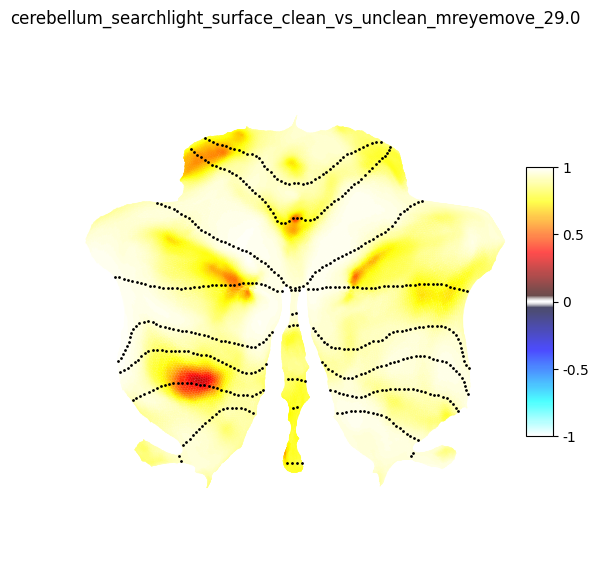

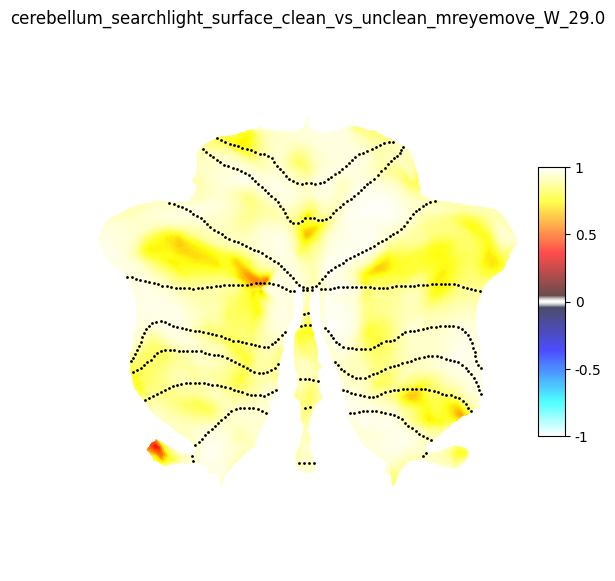

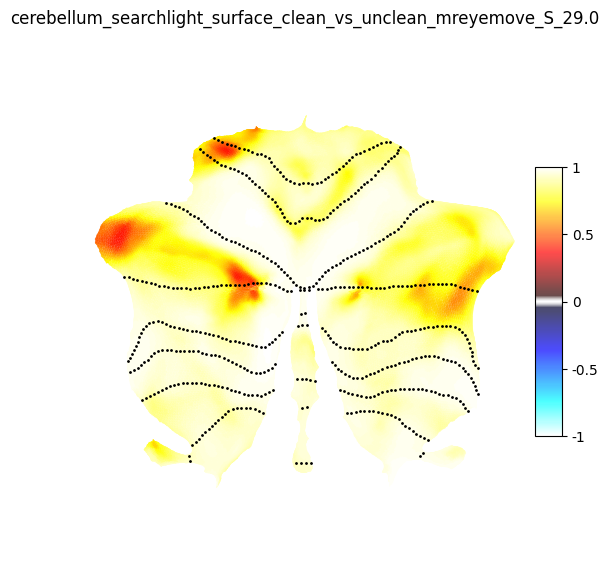

In [39]:
from mreyemove.plotting.glm import custom_cmap

"""
Cerebellum Searchlight
"""

from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation

config_main_cer = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep_cer.yml")
desc_add_main_cer = construct_desc(dataset=mrio_unclean, config=config_main_cer)
desc_add_main_cer = f"{desc_add_main_cer}-{config_main_cer.second_level.method}"
desc_add_main_cer = "clean-original-sleep-incl-nrem3-cer-cov-flame"

config_eog_cer = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep_cer.yml")
desc_add_eog_cer = construct_desc(dataset=mrio, config=config_eog_cer)
desc_add_eog_cer = f"{desc_add_eog_cer}-{desc_add_eog_cer.second_level.method}"

for contrast in comparisons:
    print(f"\n=== {contrast} clean vs unclean ===")
    title = f"cerebellum_searchlight_surface_mreyemove_vs_eog_{contrast}_{radius_mm}"
    
    vol_a,_ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add_main_cer)
    vol_b,_ = mrio_unclean.load_FLAME_result(contrast=contrast, desc_add=desc_add_unclean)
    
    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')
    
    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=cerebellum_neighbourhoods,
        min_vertices=10,
    )
    
    corr_maps[f"mreyemove_vs_eog_{contrast}"] = results
    
    ax = flatmap.plot(data=results, cmap=custom_cmap(), 
            new_figure=True, 
            colorbar=True, 
            render='matplotlib',
            cscale=[-1.0, 1.0])
    ax.set_title(title)

    output_path = FIG_DIR / f"{title}.png"

    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")


# EOG vs MReyeMove Regressor Correlation

  Skipping 16 run 1 (no EOG data)
  Skipping 16 run 2 (no EOG data)
  Skipping 16 run 3 (no EOG data)
  Skipping 16 run 4 (no EOG data)
  Skipping 16 run 5 (no EOG data)

Per-run correlations (158 runs):
21.50173157288023 [0.38276289 0.45258314]


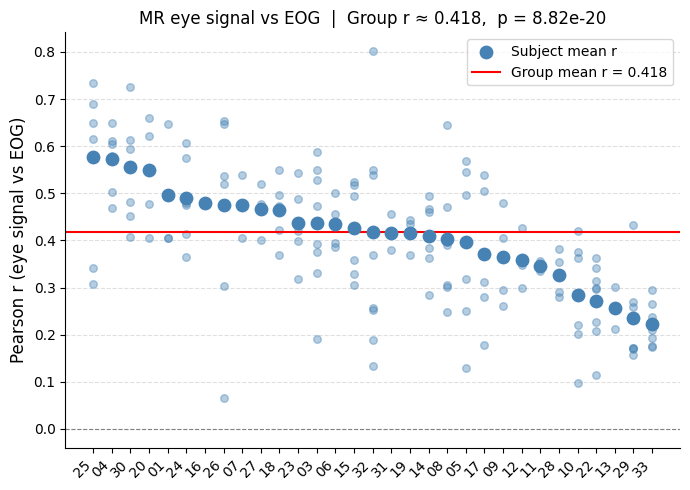

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in mrio.iter_run_events():
    eye_signal = run_df["mreyemove"]

    eog_rows = run_df["eog"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    if len(eye_signal) != len(eog_signal):
        print(f"  Skipping {subject} run {run} (length mismatch: eye={len(eye_signal)}, eog={len(eog_signal)})")
        continue

    r, _ = stats.pearsonr(eye_signal, eog_signal)  
    if np.isnan(r):
        continue

    records.append(dict(
        subject=subject,
        run=run,
        r=r,
        n=len(eye_signal),
        mean_eye=np.mean(np.abs(eye_signal)),
        mean_eog=np.mean(np.abs(eog_signal)),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean_z(r_values):
    """Return Fisher-averaged correlation in z-space."""
    return np.mean(np.arctanh(np.clip(r_values, -0.9999, 0.9999)))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(z=lambda _r: fisher_mean_z(_r.values), n_runs="count")
    .reset_index()
)
subj_df["r"] = np.tanh(subj_df["z"])  # for display only


# Group-level

z_vals = subj_df["z"].values
mean_z = z_vals.mean()

group_r = np.tanh(mean_z)

t_stat, p_val = stats.ttest_1samp(subj_df["z"].values, 0)
se_z = subj_df["z"].std(ddof=1) / np.sqrt(len(subj_df))
ci_z = mean_z + np.array([-1, 1]) * stats.t.ppf(0.975, len(subj_df)-1) * se_z
ci_r = np.tanh(ci_z)  # e.g. report group r = 0.017, 95% CI [...]

print(t_stat, ci_r)
# ── 4. Plot: per-subject mean r with individual runs ─────────────────────────

subj_plot = subj_df.sort_values("r", ascending=False).reset_index(drop=True)
p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in subj_plot.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

ax.scatter(range(len(subj_plot)), subj_plot["r"],
           color="steelblue", s=80, zorder=3, label="Subject mean r")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_plot)))
ax.set_xticklabels(subj_plot["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "mreyemove_eog_r_per_subject.svg", dpi=300)
plt.show()